#### Logistic Regression
    - Logistic Regression is a classification algorithm used to assign observations to a discrete set of classes. Unlike Linear Regression, which outputs a continuous value, Logistic Regression outputs a probability that the given input point belongs to a certain class. The output is transformed using the logistic function (also known as the sigmoid function) to produce a value between 0 and 1, which can be interpreted as a probability of belonging to a particular class.
    
    - We use logistic regression when the dependent variable is binary (0 or 1) OR Binary Classification
    - The logistic regression is used for classification tasks.

    - e.g True/False, Yes/No, Spam/Not Spam, etc. Binary classification problems.

    - Another type of classification is Multiclass classification, where the dependent variable can take more than two categories (e.g. classifying types of flowers, or types of animals).

    - Another type of classification is Multilabel classification, where the dependent variable can take multiple labels (e.g. classifying types of diseases, where a patient can have multiple diseases at the same time OR classifying types of movies, where a movie can belong to multiple genres at the same time).

    - Binary Classification, Multiclass Classification, Multilabel Classification.


- In Linear Regression, linear combination of the independent variables is used to predict the dependent variable. The output can be any real number.
- In Logistic Regression, the output is transformed using the logistic function (also known as the sigmoid function) to produce a value between 0 and 1, which can be interpreted as a probability of belonging to a particular class.

##### Logistic Regression
    Predict -> Probability of belonging to a particular class (0 or 1) where 0 is the negative class and 1 is the positive class.
    
    - Logistic Regression is based on the logistic function (sigmoid function) which maps any real-valued number into a value between 0 and 1. The logistic function is defined as:
    f(z) = 1 / (1 + e^(-z)) where z is the linear combination of the independent variables (z = b0 + b1*x1 + b2*x2 + ... + bn*xn).
    



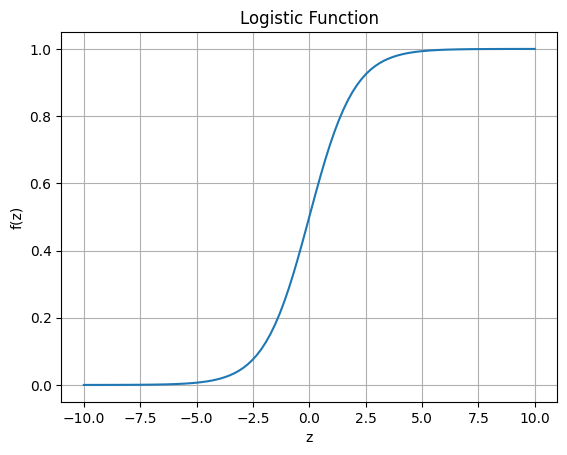

In [2]:
# Draw graph of logistic function
import numpy as np
import matplotlib.pyplot as plt 

def logistic_function(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

plt.plot(z, logistic_function(z))
plt.title('Logistic Function')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.grid()
plt.show()


- We call it regression because it outputs a number but that number is later assigned to a class using sigmoid function

- Logistic Regression can be used for:
1 - Binary Classification
2 - Multi-Class Classification
3 - One-vs-Rest Classification

#### Assumptions of Logistic Regression
- The dependent variable is binary (0 or 1) OR Categorical
- The independent variables(features) must be independent of each other (no multicollinearity)
- There should be no outliers in the data
- There should be no high correlation between the independent variables (features)

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler


In [40]:
# Load the dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
# Preprocessing

# Remove the deck column
df.drop(['deck','alive'], axis=1, inplace=True)


In [42]:
# Impute missing values in age and fair with median

df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())



In [43]:
# Impute missing values in embarked and embark_town with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True


In [44]:

# Encode categorical variables using for loop where object and category datatypes are given
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col])

C:\Users\mypci\AppData\Local\Temp\ipykernel_15628\899323848.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']).columns:


In [45]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,True


In [46]:
X = df.drop('survived', axis=1)
y = df['survived']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

c:\Users\mypci\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
# predict the model
y_pred = model.predict(X_test)

In [48]:
# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179

Confusion Matrix:
 [[91 14]
 [19 55]]
Accuracy Score: 0.8156424581005587
Recall Score: 0.7432432432432432
F1 Score: 0.7692307692307693


Text(0.5, 1.0, 'Confusion Matrix')

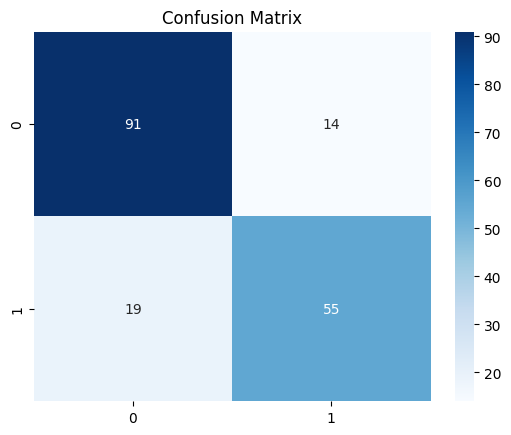

In [49]:
# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

In [50]:
# Saving the model
import pickle
pickle.dump(model, open('./savedModels/02_logisticModel.pkl', 'wb'))

In [52]:
model.predict([[3, 1, 22.0, 1, 0, 7.25, 2, 2, 1, 1, 0, False]])

c:\Users\mypci\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

#### Evaluation Metrics

- Regression
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - R-squared (R2)

- Classsification
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix